In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
df = pd.read_csv('Apple_Stock.csv')
df.head()

,Date,Close/Last,Volume,Open,High,Low
0,02/28/2020,$273.36,106721200,$257.26,$278.41,$256.37
1,02/27/2020,$273.52,80151380,$281.1,$286,$272.96
2,02/26/2020,$292.65,49678430,$286.53,$297.88,$286.5
3,02/25/2020,$288.08,57668360,$300.95,$302.53,$286.13
4,02/24/2020,$298.18,55548830,$297.26,$304.18,$289.23


In [3]:

df.drop([' Volume', ' Open', ' High', ' Low'], axis=1, inplace=True)
df.head()

df.columns = df.columns.str.strip()
df.columns

Index(['Date', 'Close/Last'], dtype='object')

In [4]:
df['Close/Last'] = df['Close/Last'].replace('[\$,]', '', regex=True).astype(float)

<>:1: SyntaxWarning: invalid escape sequence '\$'
<>:1: SyntaxWarning: invalid escape sequence '\$'
C:\Users\admin\AppData\Local\Temp\ipykernel_11664\2548826300.py:1: SyntaxWarning: invalid escape sequence '\$'
  df['Close/Last'] = df['Close/Last'].replace('[\$,]', '', regex=True).astype(float)


In [5]:

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date')
df.set_index('Date', inplace=True)

<Axes: xlabel='Date'>

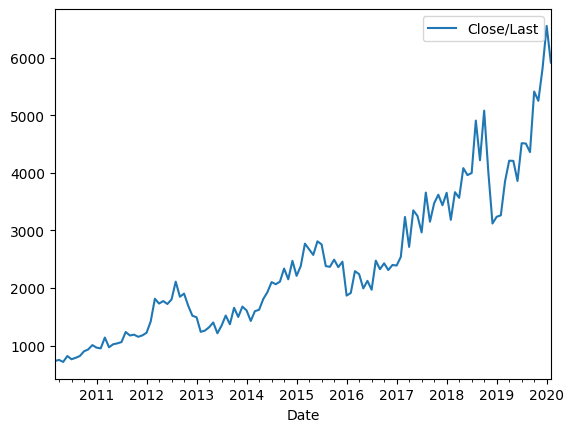

In [6]:
data_monthly = df.resample('MS').sum()   #Month start
data_monthly.head()
data_monthly.plot()

<Axes: >

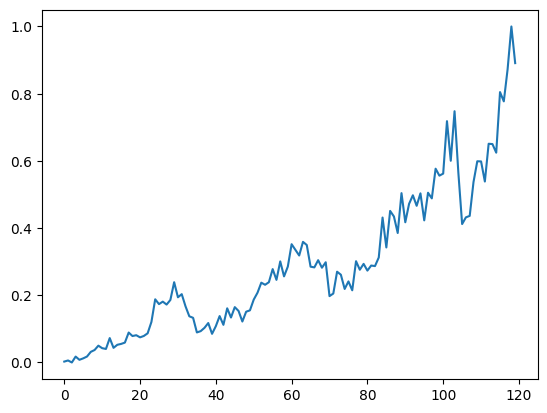

In [7]:
scaler = MinMaxScaler()
scaled_data = pd.Series(scaler.fit_transform(data_monthly.values.reshape(-1, 1)).flatten())
scaled_data.plot() 

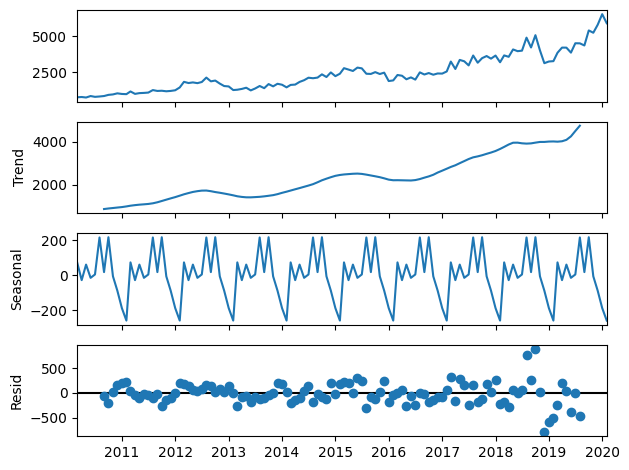

In [8]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(data_monthly, model="additive")
decomposition.plot()
plt.show()

In [9]:
scaled_data=scaled_data+1 
train_data = scaled_data[:int(len(scaled_data) * 0.8)]
test_data = scaled_data[int(len(scaled_data) * 0.8):]

In [13]:
model_add = ExponentialSmoothing(train_data, trend='add', seasonal='mul', seasonal_periods=12).fit()
test_predictions_add = model_add.forecast(steps=len(test_data))

(0.21880643254588544, 1.289754916925274)

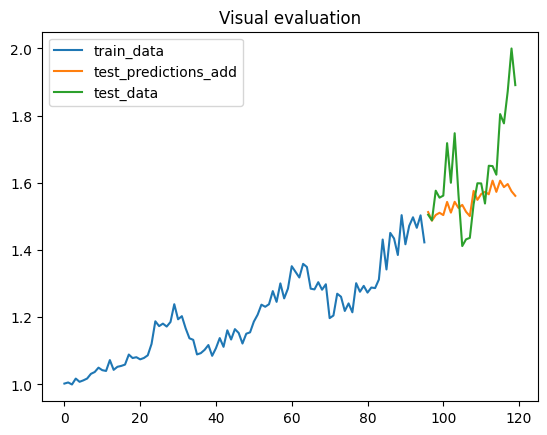

In [16]:
import numpy as np
ax=train_data.plot()
test_predictions_add.plot(ax=ax)
test_data.plot(ax=ax)
ax.legend(["train_data", "test_predictions_add","test_data"])
ax.set_title('Visual evaluation')
np.sqrt(mean_squared_error(test_data, test_predictions_add))
np.sqrt(scaled_data.var()),scaled_data.mean()

Text(0.5, 1.0, 'Prediction')

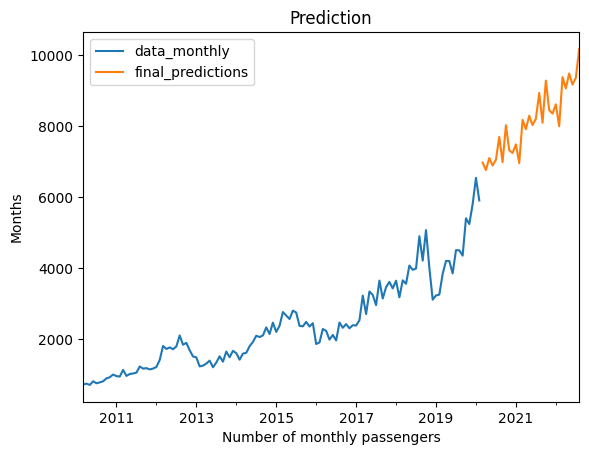

In [17]:
final_model = ExponentialSmoothing(data_monthly, trend='add', seasonal='mul', seasonal_periods=12).fit()
final_predictions = final_model.forecast(steps=int(len(data_monthly)/4)) #for next year
ax=data_monthly.plot()
final_predictions.plot(ax=ax)
ax.legend(["data_monthly", "final_predictions"])
ax.set_xlabel('Number of monthly passengers')
ax.set_ylabel('Months')
ax.set_title('Prediction')